In [39]:
# ============================================================
#            run once at the start of every session          
# ============================================================
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import os

CSV_FILE = "restaurants.csv"

if os.path.exists(CSV_FILE):
    df_loaded = pd.read_csv(CSV_FILE)
    restaurants = df_loaded.to_dict("records")
    print(f"Loaded {len(restaurants)} restaurant(s) from {CSV_FILE}")
else:
    restaurants = []
    print("No existing data found. Starting fresh.")

Loaded 1 restaurant(s) from restaurants.csv


In [40]:
print("--- Add a Restaurant ---")
name    = input("Restaurant name: ").strip()
cuisine = input("Cuisine type: ").strip()
city    = input("City: ").strip()

while True:
    try:
        koko = int(input("Koko score (1-10): "))
        if 1 <= koko <= 10:
            break
        print("Please enter a number between 1 and 10.")
    except ValueError:
        print("Please enter a whole number.")

while True:
    try:
        value = int(input("Value score (1-5): "))
        if 1 <= value <= 5:
            break
        print("Please enter a number between 1 and 5.")
    except ValueError:
        print("Please enter a whole number.")

restaurants.append({"name": name, "cuisine": cuisine, "city": city, "koko": koko, "value": value})

# Save to CSV
pd.DataFrame(restaurants).to_csv(CSV_FILE, index=False)
print(f"\nAdded '{name}'! You now have {len(restaurants)} restaurant(s) saved.")

--- Add a Restaurant ---


Restaurant name:  Thonglor
Cuisine type:  Thai
City:  Boston
Koko score (1-10):  8
Value score (1-5):  4



Added 'Thonglor'! You now have 2 restaurant(s) saved.


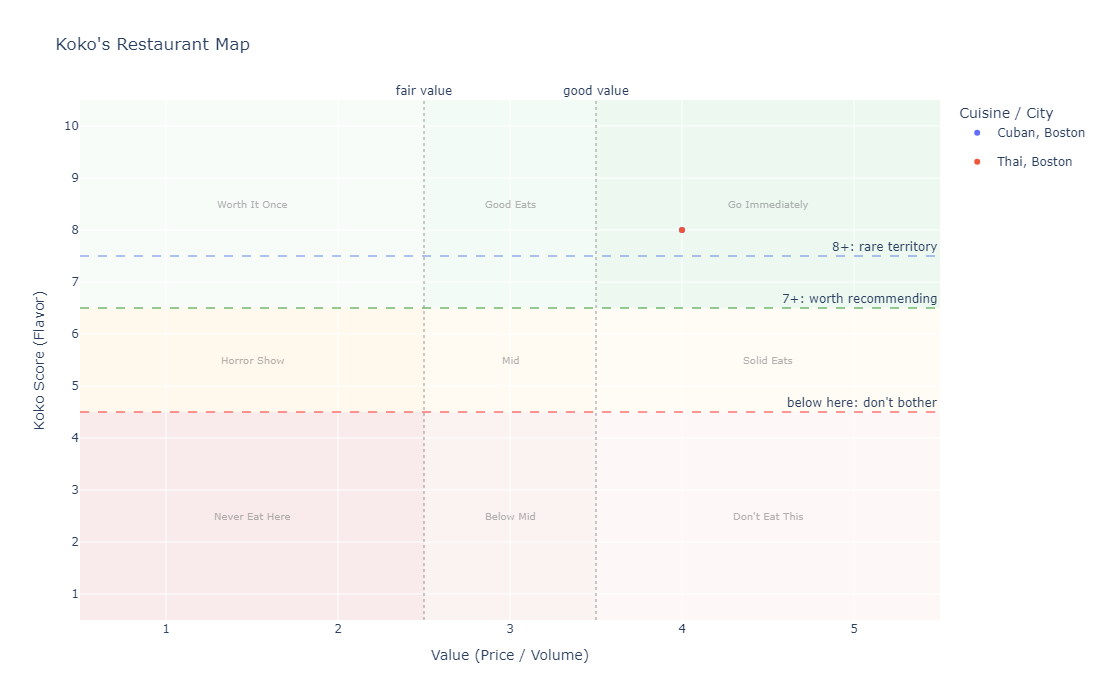

In [41]:
if not restaurants:
    print("No restaurants yet. Add some in Cell 2 first.")
else:
    df = pd.DataFrame(restaurants)

    # --- Zone definitions ---
    # (x0, x1, y0, y1, color, label)
    # Value:  0.5-2.5 = bad (1-2), 2.5-3.5 = fair (3), 3.5-5.5 = good (4-5)
    # Koko:   0.5-4.5 = bad (1-4), 4.5-6.5 = mid (5-6), 6.5-10.5 = good (7-10)
    zones = [
        # Bad food row
        (0.5, 2.5, 0.5, 4.5, "rgba(180,0,0,0.08)",     "Never Eat Here"),
        (2.5, 3.5, 0.5, 4.5, "rgba(180,0,0,0.05)",     "Below Mid"),
        (3.5, 5.5, 0.5, 4.5, "rgba(180,0,0,0.03)",     "Don't Eat This"),
        # Mid food row
        (0.5, 2.5, 4.5, 6.5, "rgba(255,160,0,0.07)",   "Horror Show"),
        (2.5, 3.5, 4.5, 6.5, "rgba(255,160,0,0.05)",   "Mid"),
        (3.5, 5.5, 4.5, 6.5, "rgba(255,160,0,0.04)",   "Solid Eats"),
        # Good food row
        (0.5, 2.5, 6.5, 10.5, "rgba(50,180,100,0.04)", "Worth It Once"),
        (2.5, 3.5, 6.5, 10.5, "rgba(50,180,100,0.06)", "Good Eats"),
        (3.5, 5.5, 6.5, 10.5, "rgba(50,180,100,0.09)", "Go Immediately"),
    ]

    fig = go.Figure()

    # Draw zones
    for x0, x1, y0, y1, color, label in zones:
        fig.add_shape(type="rect",
            x0=x0, x1=x1, y0=y0, y1=y1,
            fillcolor=color, line_width=0, layer="below"
        )
        fig.add_annotation(
            x=(x0+x1)/2, y=(y0+y1)/2,
            text=label, showarrow=False,
            font=dict(size=10, color="gray"),
            opacity=0.6
        )

    # Koko threshold lines
    thresholds = [
        (4.5, "below here: don't bother", "red"),
        (6.5, "7+: worth recommending",   "green"),
        (7.5, "8+: rare territory",        "royalblue"),
    ]
    for y, label, color in thresholds:
        fig.add_hline(y=y, line_dash="dash", line_color=color, opacity=0.4,
                      annotation_text=label, annotation_position="top right")

    # Value threshold lines
    fig.add_vline(x=2.5, line_dash="dot", line_color="gray", opacity=0.4,
                  annotation_text="fair value", annotation_position="top")
    fig.add_vline(x=3.5, line_dash="dot", line_color="gray", opacity=0.4,
                  annotation_text="good value", annotation_position="top")

    # Scatter plot — colored by cuisine, symbol by city
    scatter = px.scatter(df,
        x="value", y="koko",
        hover_name="name",
        hover_data={"cuisine": True, "city": True, "koko": True, "value": True},
        color="cuisine",
        symbol="city",
    )
    for trace in scatter.data:
        fig.add_trace(trace)

    fig.update_layout(
        title="Koko's Restaurant Map",
        xaxis=dict(title="Value (Price / Volume)", range=[0.5, 5.5], dtick=1),
        yaxis=dict(title="Koko Score (Flavor)",    range=[0.5, 10.5], dtick=1),
        plot_bgcolor="white",
        legend_title="Cuisine / City",
        width=700,
        height=700,
    )

    fig.show()

In [42]:
if restaurants:
    df_view = pd.DataFrame(restaurants).sort_values("koko", ascending=False)
    display(df_view.reset_index(drop=True))
else:
    print("No restaurants yet.")

,name,cuisine,city,koko,value
0,Mariel,Cuban,Boston,8,4
1,Thonglor,Thai,Boston,8,4


In [43]:
if not restaurants:
    print("No restaurants to delete.")
else:
    print("Current restaurants:")
    for i, r in enumerate(restaurants):
        print(f"  {i} — {r['name']} ({r['city']}) | Koko: {r['koko']} | Value: {r['value']}")

    idx = int(input("\nEnter the number of the restaurant to delete: "))
    if 0 <= idx < len(restaurants):
        removed = restaurants.pop(idx)
        pd.DataFrame(restaurants).to_csv(CSV_FILE, index=False)
        print(f"Removed '{removed['name']}'. {len(restaurants)} restaurant(s) remaining.")
    else:
        print("Invalid number.")

Current restaurants:
  0 — Mariel (Boston) | Koko: 8 | Value: 4
  1 — Thonglor (Boston) | Koko: 8 | Value: 4



Enter the number of the restaurant to delete:  0


Removed 'Mariel'. 1 restaurant(s) remaining.


In [44]:
import os
print(os.getcwd())

C:\Users\seifh
